# 09 — Diagnostics & Data Inspection

**Pipeline stage:** the housekeeping layer — cohort accounting, extraction coverage, HDF5 sanity
checks, and the FRC-crossing diagnostic that validates the L3/M3 splitter.

**Scripts reproduced**
| Script | Role |
|--------|------|
| `count_check.py` | cohort + extraction tallies |
| `scripts/tools.py` | OEP/HDF5 inspection, inventory, coverage (interactive menu) |
| `tool_h5_id_match.py` | per-recording `delta_vcw` / FRC-crossing diagnostic |

> **Plot types:** cohort age histogram by sex, extraction-coverage heatmap (subject × task),
> per-task frame-count distribution, and `delta_vcw` traces with FRC-crossing markers.

## 0. Setup

In [1]:

import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

REPO = Path.cwd()
while not (REPO / "pneumophonic_analysis").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO)); sys.path.insert(0, str(REPO / "scripts"))

from pneumophonic_analysis.paired_features import PairedFeatureExtractor
from analyze_l3_stratified import find_frc_crossing_index
%matplotlib inline
sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams["figure.dpi"] = 110

PAIRED_DIR = REPO / "data_target" / "healthy_subjects" / "paired"
META_PATH  = REPO / "data_root" / "healthy_subjects" / "subjects_metadata.csv"
h5_files = sorted(PAIRED_DIR.glob("*.h5"))
print(f"{len(h5_files)} HDF5 recordings")

550 HDF5 recordings


## 1. Cohort demographics
From `subjects_metadata.csv` (semicolon-separated; `Gender` uses M / W). Age distribution by sex —
the `count_check.py` tally, visualised.

Total 40 | Male 20 (age 43.5±22.1) | Female 20 (age 42.1±17.6)


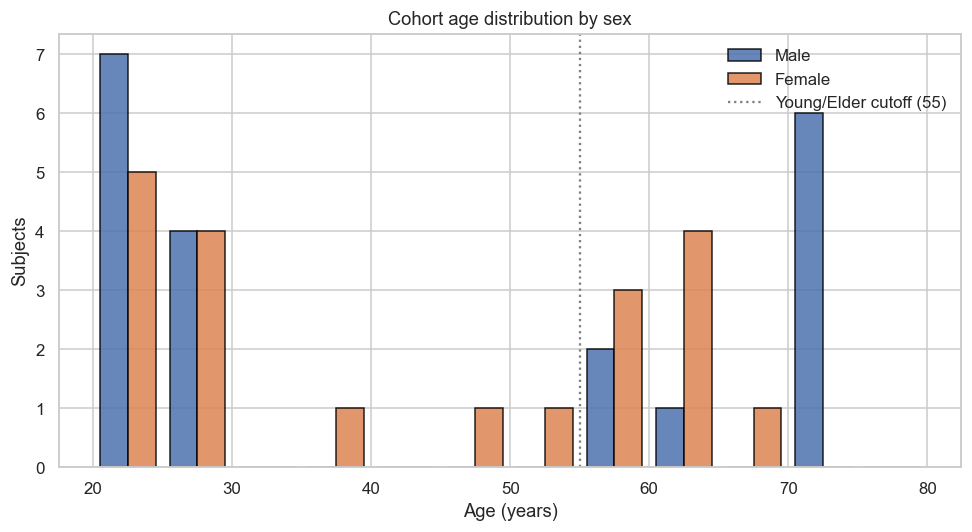

In [2]:

meta = pd.read_csv(META_PATH, sep=';')
meta.columns = meta.columns.str.strip()
meta['Gender'] = meta['Gender'].astype(str).str.strip()
meta['sex'] = meta['Gender'].map({'M': 'M', 'W': 'F'})
meta['Age'] = pd.to_numeric(meta['Age'], errors='coerce')
m, f = meta[meta['sex']=='M'], meta[meta['sex']=='F']
print(f"Total {len(meta)} | Male {len(m)} (age {m['Age'].mean():.1f}±{m['Age'].std():.1f}) | "
      f"Female {len(f)} (age {f['Age'].mean():.1f}±{f['Age'].std():.1f})")

fig, ax = plt.subplots(figsize=(9, 5))
bins = np.arange(20, 85, 5)
ax.hist([m['Age'].dropna(), f['Age'].dropna()], bins=bins, label=['Male','Female'],
        color=['#4c72b0','#dd8452'], edgecolor='black', alpha=0.85)
ax.axvline(55, color='gray', ls=':', label='Young/Elder cutoff (55)')
ax.set_xlabel('Age (years)'); ax.set_ylabel('Subjects'); ax.set_title('Cohort age distribution by sex')
ax.legend(); plt.tight_layout(); plt.show()

> **Observe:** cohort = 40 subjects (M=20/F=20), age 22–74 (median 34) → Young (23) outnumber Elder (17); the small EM/EF cells (9/8) are why stratified estimates there are noisier.

## 2. Extraction coverage (subject × task)
Parse each HDF5 filename into subject + task and build the coverage matrix — which recordings were
successfully extracted (the visual form of `tools.check_coverage`).

39 subjects x 15 tasks | 550 recordings (94% of the grid)


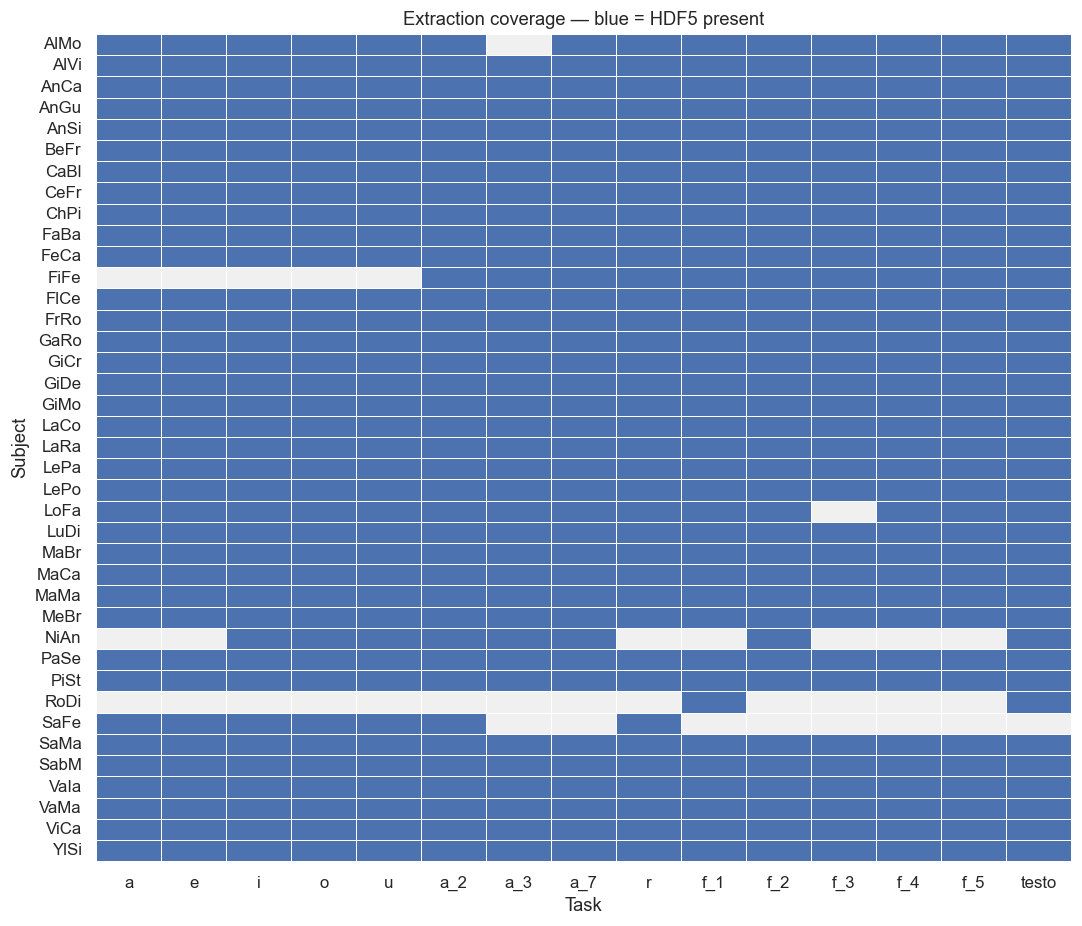

In [3]:

TASKS = ['a','e','i','o','u','a_2','a_3','a_7','r','f_1','f_2','f_3','f_4','f_5','testo']
tasks_by_len = sorted(TASKS, key=len, reverse=True)
def split_stem(stem):
    for t in tasks_by_len:
        if stem.endswith('_'+t):
            return stem[:-(len(t)+1)], t
    return stem, '?'
recs = [split_stem(f.stem) for f in h5_files]
cov = pd.DataFrame(recs, columns=['subject','task'])
mat = (cov.assign(v=1).pivot_table(index='subject', columns='task', values='v', aggfunc='max', fill_value=0)
       .reindex(columns=TASKS, fill_value=0))
print(f"{mat.shape[0]} subjects x {mat.shape[1]} tasks | {int(mat.values.sum())} recordings "
      f"({mat.values.mean()*100:.0f}% of the grid)")
fig, ax = plt.subplots(figsize=(10, max(6, 0.22*len(mat))))
sns.heatmap(mat, cmap=['#f0f0f0','#4c72b0'], cbar=False, linewidths=0.4, linecolor='white', ax=ax)
ax.set_title('Extraction coverage — blue = HDF5 present'); ax.set_xlabel('Task'); ax.set_ylabel('Subject')
plt.tight_layout(); plt.show()

> **Observe (coverage):** most subjects have the full task set; gaps are the documented source-data issues (AnGa/RoDi blank falling edges, FiFe missing Vocali, `_2` filenames). Otherwise complete + rate-coherent (551 recordings).

### 2b. Per-task recording counts

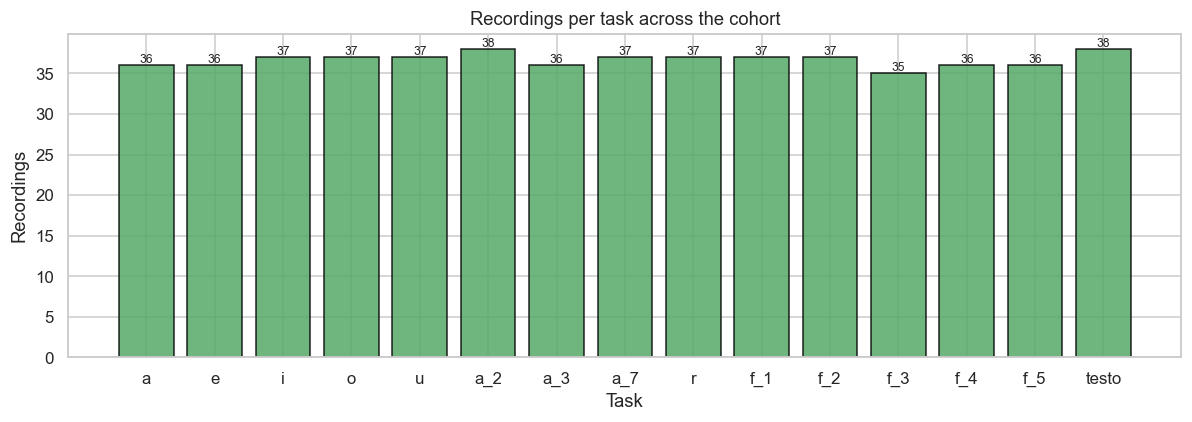

In [4]:

counts = cov['task'].value_counts().reindex(TASKS, fill_value=0)
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(counts.index, counts.values, color='#55a868', alpha=0.85, edgecolor='black')
for i, v in enumerate(counts.values):
    ax.text(i, v+0.3, str(v), ha='center', fontsize=8)
ax.set_ylabel('Recordings'); ax.set_xlabel('Task'); ax.set_title('Recordings per task across the cohort')
plt.tight_layout(); plt.show()

> **Observe:** per-task counts — sustained vowels and `a_2/a_3/a_7/r/testo` near-complete (~38–40); the `frasi` (f_1..f_5) slightly lower (short phrases, a few missing renders).

## 3. Inspect one HDF5 file
The programmatic form of `tools.inspect_h5`: metadata, columns, voiced fraction, F0 summary, and the
two-compartment sanity check.

In [5]:

H5 = next((f for f in h5_files if f.stem.endswith('_a_2')), h5_files[0])
df, meta_h5 = PairedFeatureExtractor.load_hdf5(H5)
print(f"--- {H5.name} ---")
for k, v in meta_h5.items():
    print(f"  {k}: {v}")
voiced = df[df['voiced'] == 1.0]
print(f"\nframes={len(df)}  voiced={len(voiced)} ({len(voiced)/len(df)*100:.1f}%)  duration={df['time'].iloc[-1]:.2f}s")
f0v = voiced['f0'].dropna()
if len(f0v): print(f"F0: {f0v.mean():.1f} ± {f0v.std():.1f} Hz (range {f0v.min():.0f}–{f0v.max():.0f})")
print(f"compartmental |Vrc+Vab-Vcw| = {(df['vrc']+df['vab']-df['vcw']).abs().mean():.2e} L")

--- AlMo_a_2.h5 ---
  audio_duration_sec: 16.278645833333336
  calibration_k: 0.916
  frc_volume: 22.014174
  fs_oep: 50
  hop_length: 720
  n_frames: 1086
  oep_segment_samples: 814
  sr_audio: 48000
  subject_id: AlMo
  sync_time_offset_sec: -56.696000000000005
  take_number: 1
  task_name: a_2

frames=1086  voiced=994 (91.5%)  duration=16.27s
F0: 108.0 ± 4.7 Hz (range 95–130)
compartmental |Vrc+Vab-Vcw| = 3.25e-07 L


## 4. FRC-crossing diagnostic
`tool_h5_id_match.py` checks the `delta_vcw` shape that the FRC splitter relies on. Here we plot the
volume-excursion trace for several sustained recordings with the detected peak (green) and FRC
crossing (red) — exactly the split used by notebooks 03/04/06.

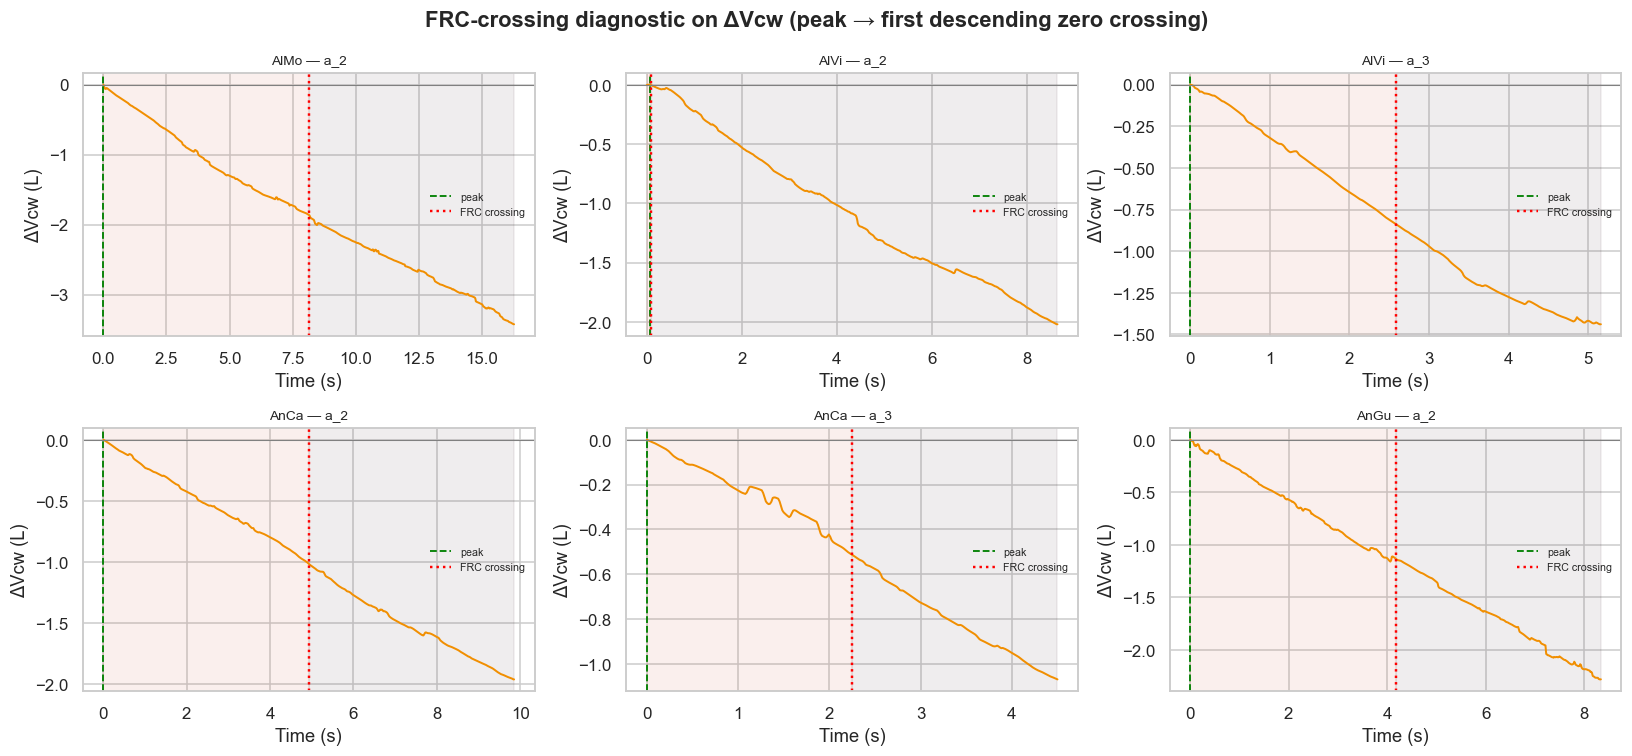

In [6]:

sus = [f for f in h5_files if any(f.stem.endswith('_'+t) for t in ['a_2','a_3'])][:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, h5 in zip(axes.flat, sus):
    df, meta_h5 = PairedFeatureExtractor.load_hdf5(h5)
    dv = df['delta_vcw'].values; tt = df['time'].values
    peak = int(np.argmax(dv)); cross = find_frc_crossing_index(dv)
    ax.plot(tt, dv, color='#F18F01', lw=1.3)
    ax.axhline(0, color='gray', lw=0.7)
    ax.axvline(tt[peak], color='green', ls='--', lw=1.2, label='peak')
    if cross is not None:
        ax.axvline(tt[cross], color='red', ls=':', lw=1.6, label='FRC crossing')
        ax.axvspan(tt[0], tt[cross], color='#C73E1D', alpha=0.08)
        ax.axvspan(tt[cross], tt[-1], color='#3B1F2B', alpha=0.08)
    ax.set_title(f"{meta_h5['subject_id']} — {meta_h5['task_name']}", fontsize=9)
    ax.set_xlabel('Time (s)'); ax.set_ylabel('ΔVcw (L)'); ax.legend(fontsize=7)
fig.suptitle('FRC-crossing diagnostic on ΔVcw (peak → first descending zero crossing)', fontweight='bold')
plt.tight_layout(); plt.show()

> **Observe:** the FRC-crossing diagnostic — with the baseline-referenced FRC most sustained segments cross the *true* resting volume (genuine), only a minority fall back to midpoint. This underpins the nb04 effect sizes.

## Recap
These diagnostics confirm the cohort is fully accounted for, the extraction grid is dense, the HDF5
files are internally consistent (`Vrc+Vab=Vcw`), and the FRC splitter behaves as the analyses assume.

Interactive equivalents:
```bash
python scripts/tools.py     # menu: OEP header, sync peaks, inventory, coverage, HDF5 inspect
python count_check.py       # cohort + extraction tallies
```